# 2 - Direction classification at 6h & 12h horizons

1-hour returns are ~all noise, so instead of fitting return *magnitude* we predict **direction** (does price rise over the next **6h** / **12h**?) as classification. Longer horizons have better signal-to-noise and let news/sentiment effects play out.

**Models:** LogReg, RandomForest, XGBoost (+ optional LSTM), each across **price / price+news / price+news+sent**.

**Judge by:** accuracy & ROC-AUC **vs the majority-class baseline / 0.5** -- not by visual fit. A few points above baseline is a real result.

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

df = pd.read_csv('btc_features.csv', index_col=0, parse_dates=True).sort_index()
print(df.shape)
df.head()

(3120, 18)


,close,volume,ret_1h,ret_3h,vol_change,rsi_14,macd,macd_signal,sma20_ratio,bb_pct,btc_mentions,n_articles,total_coin_mentions,sent_mean,btc_share,sent_net,btc_sent_mean,btc_mentions_3h
datetime,,,,,,,,,,,,,,,,,,
2025-07-17 00:00:00+00:00,118894.33,3.796278e+07,0.002225,-0.003381,-0.069338,52.414603,268.531395,321.306935,0.000082,0.505253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-07-17 01:00:00+00:00,118149.70,1.010368e+08,-0.006263,-0.004127,1.661470,44.882633,183.836126,293.812773,-0.006298,0.071777,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-07-17 02:00:00+00:00,118330.57,7.190581e+07,0.001531,-0.002528,-0.288321,46.879411,129.812811,261.012781,-0.004800,0.170854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-07-17 03:00:00+00:00,118128.80,5.339443e+07,-0.001705,-0.006439,-0.257439,44.924188,69.911892,222.792603,-0.006472,0.061424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-07-17 04:00:00+00:00,118485.40,4.604592e+07,0.003019,0.002841,-0.137627,48.974694,50.630979,188.360278,-0.003382,0.274540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Setup: features, models, horizons

In [113]:
price_features = ['close', 'volume', 'ret_1h', 'ret_3h', 'vol_change',
                  'rsi_14', 'macd', 'macd_signal', 'sma20_ratio', 'bb_pct']
news_features = ['btc_mentions', 'n_articles', 'total_coin_mentions', 'btc_share', 'btc_mentions_3h']
sentiment_features = ['sent_mean', 'sent_net', 'btc_sent_mean']

feat_sets = {
    'price': price_features,
    'price+news': price_features + news_features,
    'price+news+sent': price_features + news_features + sentiment_features,
}
HORIZONS = [6, 12]

clf_factories = {
    'logreg': lambda: make_pipeline(StandardScaler(),
                                    LogisticRegression(max_iter=1000, class_weight='balanced')),
    'rf': lambda: RandomForestClassifier(n_estimators=300, random_state=0, class_weight='balanced'),
    'xgb': lambda: XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 eval_metric='logloss', random_state=0),
}

def direction_target(h):
    """Up/down over the next h hours; mask drops the last h rows (no future price)."""
    future = df['close'].shift(-h)
    y = (future > df['close']).astype(int).values
    mask = future.notna().values
    return y[mask], mask

def eval_clf(model, X, y, n):
    Xtr, Xte, ytr, yte = X[:n], X[n:], y[:n], y[n:]
    model.fit(Xtr, ytr)
    p = model.predict(Xte)
    try:
        proba = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, proba) if len(set(yte)) > 1 else float('nan')
    except Exception:
        auc = float('nan')
    return accuracy_score(yte, p), f1_score(yte, p, zero_division=0), auc

## Experiment: horizon x model x feature set

In [114]:
rows = []
for h in HORIZONS:
    y, mask = direction_target(h)
    n = int(len(y) * 0.8)
    base = max(y.mean(), 1 - y.mean())
    for mname, mk in clf_factories.items():
        for fname, feats in feat_sets.items():
            X = df[feats].values[mask]
            acc, f1, auc = eval_clf(mk(), X, y, n)
            rows.append({'horizon': f'{h}h', 'model': mname, 'features': fname,
                         'acc': round(acc, 3), 'f1': round(f1, 3), 'auc': round(auc, 3),
                         'baseline': round(base, 3)})
results = pd.DataFrame(rows)
results

,horizon,model,features,acc,f1,auc,baseline
0,6h,logreg,price,0.457,0.621,0.602,0.503
1,6h,logreg,price+news,0.472,0.626,0.593,0.503
2,6h,logreg,price+news+sent,0.467,0.619,0.588,0.503
3,6h,rf,price,0.464,0.607,0.564,0.503
4,6h,rf,price+news,0.480,0.620,0.565,0.503
5,6h,rf,price+news+sent,0.457,0.607,0.560,0.503
6,6h,xgb,price,0.470,0.626,0.494,0.503
7,6h,xgb,price+news,0.475,0.629,0.496,0.503
8,6h,xgb,price+news+sent,0.467,0.620,0.552,0.503
9,12h,logreg,price,0.404,0.563,0.585,0.506


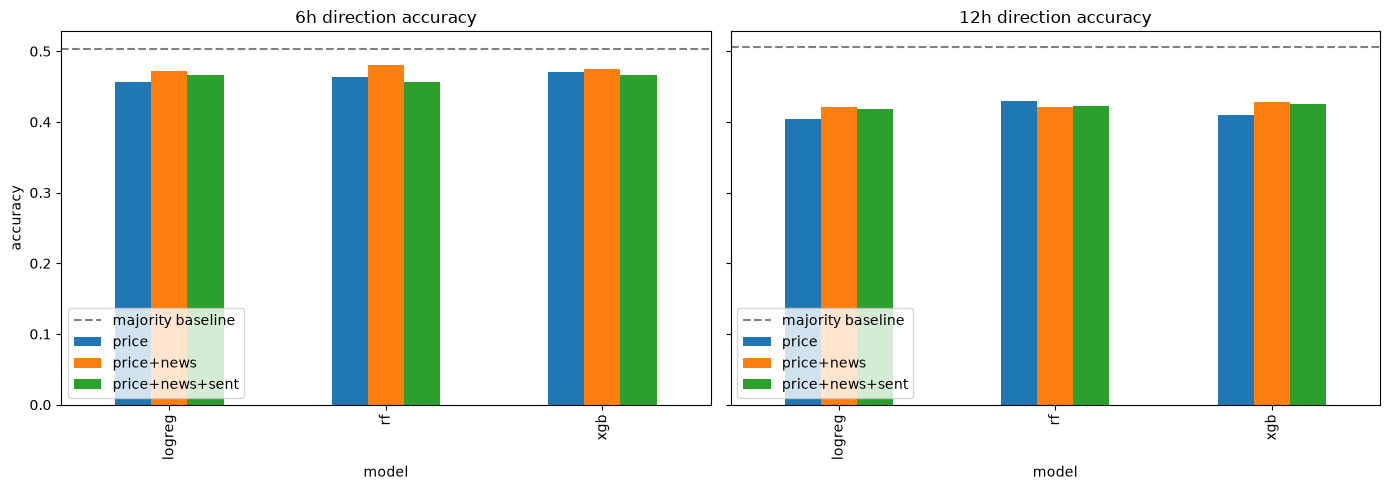

In [115]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7 * len(HORIZONS), 5), sharey=True)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    sub = results[results['horizon'] == f'{h}h']
    sub.pivot(index='model', columns='features', values='acc')[list(feat_sets)].plot(kind='bar', ax=ax)
    ax.axhline(sub['baseline'].iloc[0], ls='--', c='grey', label='majority baseline')
    ax.set_title(f'{h}h direction accuracy'); ax.set_ylabel('accuracy'); ax.legend()
plt.tight_layout(); plt.show()

## Walk-forward validation (rolling folds)

The single chronological split lands the entire test set in one regime (the Nov crash), which is why those numbers came out below 0.5. **Walk-forward** uses an expanding-window `TimeSeriesSplit` across several train->test folds spanning different regimes, then averages -- far more trustworthy. Expect numbers to regress toward ~0.5 (honest 'little/no edge').

In [116]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5

def walk_forward(mk, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    accs, aucs = [], []
    for tr, te in tscv.split(X):
        m = mk().fit(X[tr], y[tr])
        accs.append(accuracy_score(y[te], m.predict(X[te])))
        try:
            pr = m.predict_proba(X[te])[:, 1]
            aucs.append(roc_auc_score(y[te], pr) if len(set(y[te])) > 1 else np.nan)
        except Exception:
            aucs.append(np.nan)
    return np.mean(accs), np.std(accs), np.nanmean(aucs)

wf_rows = []
for h in HORIZONS:
    y, mask = direction_target(h)
    for mname, mk in clf_factories.items():
        for fname, feats in feat_sets.items():
            X = df[feats].values[mask]
            am, asd, aucm = walk_forward(mk, X, y)
            wf_rows.append({'horizon': f'{h}h', 'model': mname, 'features': fname,
                            'acc_mean': round(am, 3), 'acc_std': round(asd, 3),
                            'auc_mean': round(aucm, 3)})
wf_results = pd.DataFrame(wf_rows)
wf_results

,horizon,model,features,acc_mean,acc_std,auc_mean
0,6h,logreg,price,0.499,0.046,0.546
1,6h,logreg,price+news,0.491,0.028,0.539
2,6h,logreg,price+news+sent,0.495,0.028,0.535
3,6h,rf,price,0.497,0.026,0.519
4,6h,rf,price+news,0.510,0.034,0.518
5,6h,rf,price+news+sent,0.503,0.033,0.522
6,6h,xgb,price,0.495,0.033,0.517
7,6h,xgb,price+news,0.496,0.040,0.520
8,6h,xgb,price+news+sent,0.494,0.041,0.526
9,12h,logreg,price,0.493,0.064,0.562


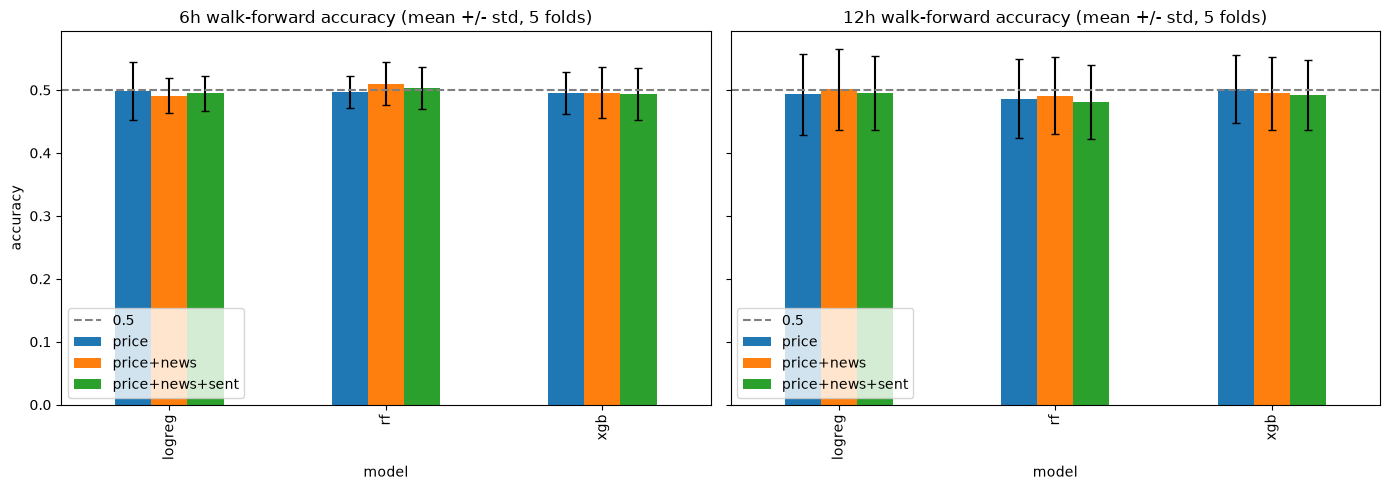

In [117]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(7 * len(HORIZONS), 5), sharey=True)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    sub = wf_results[wf_results['horizon'] == f'{h}h']
    piv = sub.pivot(index='model', columns='features', values='acc_mean')[list(feat_sets)]
    err = sub.pivot(index='model', columns='features', values='acc_std')[list(feat_sets)]
    piv.plot(kind='bar', yerr=err, ax=ax, capsize=3)
    ax.axhline(0.5, ls='--', c='grey', label='0.5')
    ax.set_title(f'{h}h walk-forward accuracy (mean +/- std, {N_SPLITS} folds)')
    ax.set_ylabel('accuracy'); ax.legend()
plt.tight_layout(); plt.show()

## Best configurations (by AUC)

In [118]:
results.sort_values('auc', ascending=False).head(10)

,horizon,model,features,acc,f1,auc,baseline
0,6h,logreg,price,0.457,0.621,0.602,0.503
1,6h,logreg,price+news,0.472,0.626,0.593,0.503
2,6h,logreg,price+news+sent,0.467,0.619,0.588,0.503
10,12h,logreg,price+news,0.421,0.568,0.587,0.506
9,12h,logreg,price,0.404,0.563,0.585,0.506
12,12h,rf,price,0.429,0.564,0.582,0.506
11,12h,logreg,price+news+sent,0.418,0.565,0.579,0.506
14,12h,rf,price+news+sent,0.423,0.566,0.577,0.506
4,6h,rf,price+news,0.480,0.620,0.565,0.503
3,6h,rf,price,0.464,0.607,0.564,0.503


## Optional: LSTM classifier (price+news+sent). Needs TensorFlow; skips if absent.

In [119]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Input
    from tensorflow.keras.callbacks import EarlyStopping
    HAVE_TF = True
except Exception as e:
    HAVE_TF = False
    print('TensorFlow not available -> skipping LSTM:', e)

if HAVE_TF:
    tf.random.set_seed(0)
    L = 24
    feats_all = price_features + news_features + sentiment_features
    closev = df['close'].values
    lstm_rows = []
    for h in HORIZONS:
        scaler = StandardScaler().fit(df[feats_all].values[:int(len(df) * 0.8)])
        Xs = scaler.transform(df[feats_all].values)
        Xo, yo, idx = [], [], []
        for i in range(L - 1, len(df) - h):
            Xo.append(Xs[i - L + 1:i + 1]); yo.append(int(closev[i + h] > closev[i])); idx.append(i)
        Xo, yo, idx = np.array(Xo), np.array(yo), np.array(idx)
        tr = idx < int(len(df) * 0.8)
        model = Sequential([Input((L, len(feats_all))), LSTM(32), Dense(1, activation='sigmoid')])
        model.compile(optimizer='adam', loss='binary_crossentropy')
        model.fit(Xo[tr], yo[tr], validation_split=0.1, epochs=40, batch_size=32,
                  callbacks=[EarlyStopping(patience=6, restore_best_weights=True)], verbose=0)
        proba = model.predict(Xo[~tr], verbose=0).ravel()
        pred = (proba > 0.5).astype(int)
        yte = yo[~tr]
        lstm_rows.append({'horizon': f'{h}h', 'model': 'lstm', 'features': 'price+news+sent',
                          'acc': round(accuracy_score(yte, pred), 3),
                          'auc': round(roc_auc_score(yte, proba), 3)})
    pd.DataFrame(lstm_rows)

## Visualize the output

Pick one (model, horizon, feature set) and look at its predictions on the test set: BTC price colored by predicted direction, the predicted P(up) over time, and a confusion matrix.

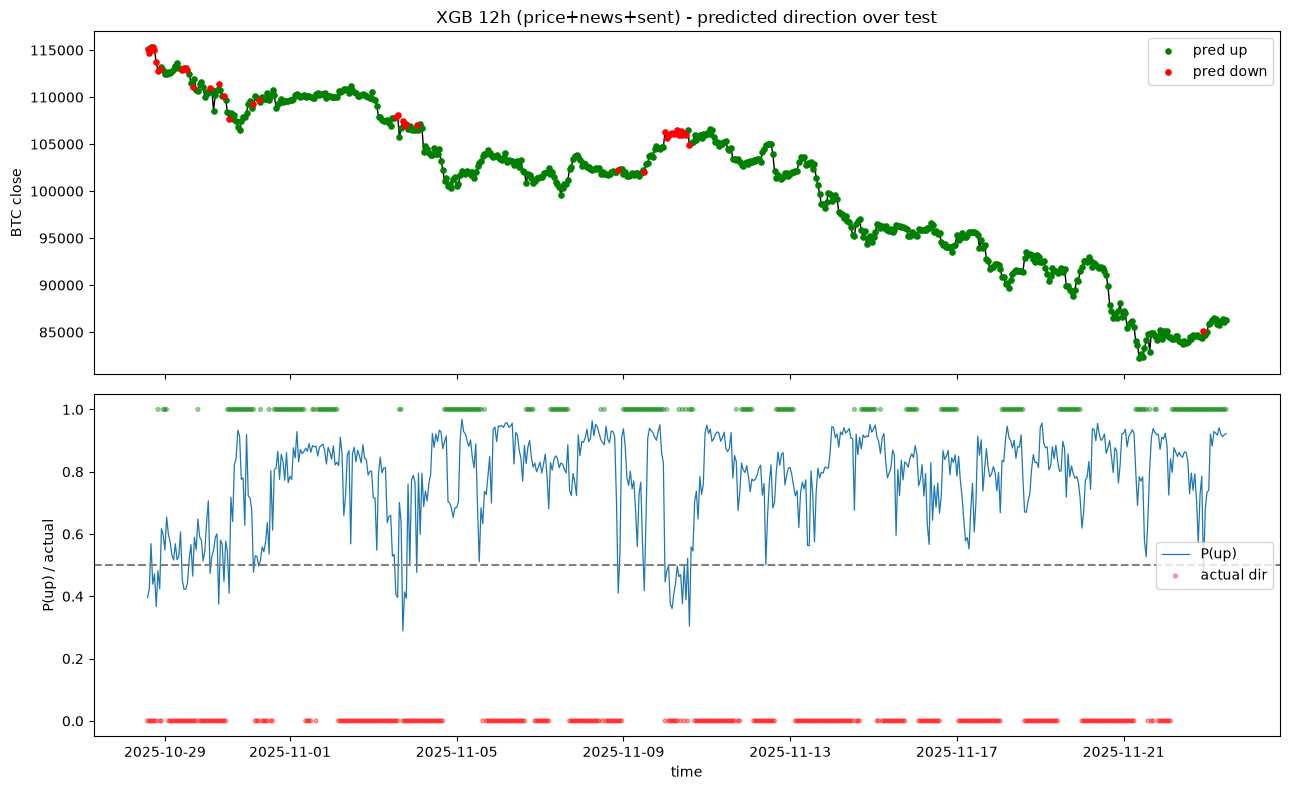

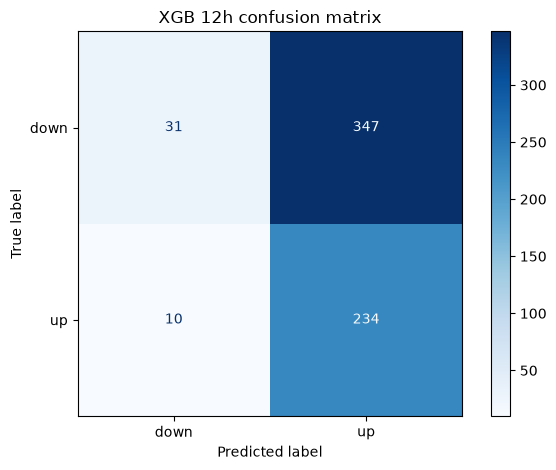

test accuracy: 0.426 | AUC: 0.545 | actual up-rate: 0.392


In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

VIZ_MODEL = 'xgb'                 # 'logreg' | 'rf' | 'xgb'
VIZ_HORIZON = 12                  # 6 or 12
VIZ_FEATURES = 'price+news+sent'  # key of feat_sets

y, mask = direction_target(VIZ_HORIZON)
n = int(len(y) * 0.8)
feats = feat_sets[VIZ_FEATURES]
X = df[feats].values[mask]
idx = df.index[mask]
close_all = df['close'].values[mask]

model = clf_factories[VIZ_MODEL]().fit(X[:n], y[:n])
proba = model.predict_proba(X[n:])[:, 1]
pred = (proba > 0.5).astype(int)
yte = y[n:]
test_idx = idx[n:]
close_te = close_all[n:]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(test_idx, close_te, color='black', lw=1.0, zorder=1)
up = pred == 1
axes[0].scatter(test_idx[up], close_te[up], c='green', s=14, label='pred up', zorder=2)
axes[0].scatter(test_idx[~up], close_te[~up], c='red', s=14, label='pred down', zorder=2)
axes[0].set_title(f'{VIZ_MODEL.upper()} {VIZ_HORIZON}h ({VIZ_FEATURES}) - predicted direction over test')
axes[0].set_ylabel('BTC close'); axes[0].legend()
axes[1].plot(test_idx, proba, color='tab:blue', lw=0.9, label='P(up)')
axes[1].axhline(0.5, ls='--', c='grey')
axes[1].scatter(test_idx, yte, c=np.where(yte == 1, 'green', 'red'), s=8, alpha=0.35, label='actual dir')
axes[1].set_ylabel('P(up) / actual'); axes[1].set_xlabel('time'); axes[1].legend()
plt.tight_layout(); plt.show()

ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=['down', 'up']).plot(cmap='Blues')
plt.title(f'{VIZ_MODEL.upper()} {VIZ_HORIZON}h confusion matrix'); plt.tight_layout(); plt.show()
print('test accuracy:', round((pred == yte).mean(), 3),
      '| AUC:', round(roc_auc_score(yte, proba), 3),
      '| actual up-rate:', round(yte.mean(), 3))

## Actual vs predicted: close, volume, return (regression)

XGB (price+news+sent) predicts the next-hour **change** (log-return for close & volume), then the level is **reconstructed one-step**: `predicted = current_value * exp(pred_change)`. Predicting the *change* instead of the absolute level avoids the tree-extrapolation flat-line -- the prediction is anchored to the actual current value, so it can follow moves into ranges never seen in training.

> close & volume will still *look* tight (that's mostly the one-step anchor / autocorrelation); the **return** panel is the honest view of skill.

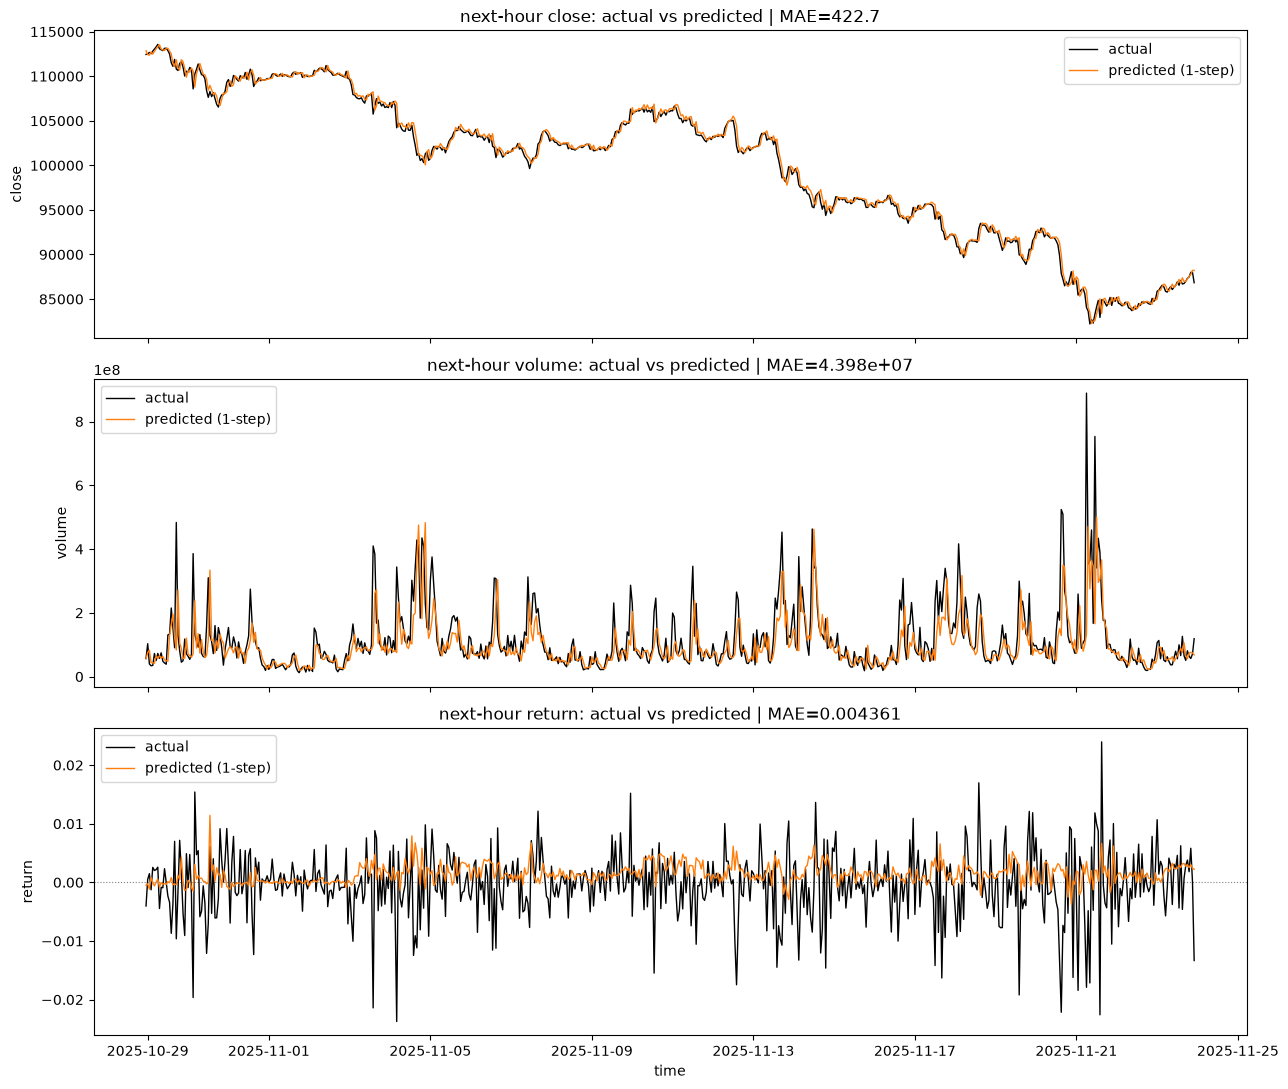

In [121]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

feats = feat_sets['price+news+sent']
w = df.copy()
# Predict the next-hour CHANGE (log); reconstruct level one-step from the actual current
# value -> no extrapolation, and both actual & predicted are rebuilt the same way (no NaN).
w['lr_close'] = np.log(w['close'].shift(-1) / w['close'])
w['lr_volume'] = np.log(w['volume'].shift(-1) / w['volume'].replace(0, np.nan))
w['ret'] = w['close'].pct_change().shift(-1)
w = w.dropna(subset=['lr_close', 'lr_volume', 'ret'])
n_reg = int(len(w) * 0.8)
tidx = w.index[n_reg:]
X = w[feats].values

panels = [('close', 'lr_close', w['close']),
          ('volume', 'lr_volume', w['volume']),
          ('return', 'ret', None)]
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (name, tgt, cur) in zip(axes, panels):
    y = w[tgt].values
    m = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0).fit(X[:n_reg], y[:n_reg])
    pred = m.predict(X[n_reg:])
    if name == 'return':
        actual, predicted = y[n_reg:], pred
        ax.axhline(0, ls=':', c='grey', lw=0.8)
    else:
        cur_te = cur.values[n_reg:]
        actual = cur_te * np.exp(y[n_reg:])      # true next value (from actual change)
        predicted = cur_te * np.exp(pred)        # predicted next value (one-step anchored)
    ax.plot(tidx, actual, color='black', lw=1.0, label='actual')
    ax.plot(tidx, predicted, color='tab:orange', lw=1.0, label='predicted (1-step)')
    ax.set_title(f'next-hour {name}: actual vs predicted | MAE={mean_absolute_error(actual, predicted):.4g}')
    ax.set_ylabel(name); ax.legend()
axes[-1].set_xlabel('time')
plt.tight_layout(); plt.show()

## Interpretation

- Compare each model's accuracy/AUC **vs the majority baseline** (dashed line). Beating it by a few points at 6h/12h = a real (if small) edge.
- Does **price+news+sent** beat **price+news** and **price**? That's whether FinBERT sentiment adds directional signal once the horizon is long enough to be less noisy.
- AUC > 0.5 is the cleanest 'is there any signal' check (threshold-independent).
- If even 6h/12h sit at ~baseline, the next levers are 24h horizon, a trading-cost-aware metric, and walk-forward validation.